In [1]:
import time
from gallop.structure import Structure
from gallop.optim import local
from gallop.optim import Swarm

In [2]:
# Create a Structure object, then add data and Z-matrices
mystructure = Structure(name="Famotidine", ignore_H_atoms=True)
mystructure.add_data("./gallop/example_data/Famotidine.sdi", source="DASH")
mystructure.add_zmatrix("./gallop/example_data/FOGVIG03_1.zmatrix")

Added Z-matrix with Filename: ./gallop/example_data/FOGVIG03_1.zmatrix
Non-H atoms: 20
refinable torsions: 7
Degrees of freedom: 14 (7 + 7)


In [3]:
# Create swarm object and get the initial particle positions.
# This will initialise 10k particles, split into
# 10 independent swarms.
swarm = Swarm(mystructure, n_particles=10000, n_swarms=10)
external, internal = swarm.get_initial_positions()

Total degrees of freedom: 14
Total external degrees of freedom: 7 (pos: 3 rot: 4 )
Total internal degrees of freedom: 7


100%|██████████| 10/10 [00:00<00:00, 1432.24it/s]


In [4]:
# Get the minimiser settings and optionally modify them
minimiser_settings = local.get_minimiser_settings(mystructure)
minimiser_settings["n_iterations"] = 500
minimiser_settings["save_CIF"] = True

In [5]:
# Automatically set the learning rate (aka step size) for the local optimiser
lr = local.find_learning_rate(mystructure, external=external,
        internal=internal, minimiser_settings=minimiser_settings)
minimiser_settings["learning_rate"] = lr[-1]

  0%|          | 0/200 [00:00<?, ?it/s]/home/riko/repo/gallop/gallop/zm_to_cart.py:218: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:62.)
  cart_coords = zm_to_cart(internal[:,torsion[i]], initial_D2[i],
GALLOP iter 0000 LO iter 0200 min chi2 537.9: 100%|██████████| 200/200 [00:05<00:00, 39.19it/s]


In [6]:
# Set the total number of iterations for the GALLOP run
gallop_iters = 10

In [7]:
# The main GALLOP loop
start_time = time.time()
for i in range(gallop_iters):
    # Local optimisation of particle positions
    result = local.minimise(mystructure, external=external, internal=internal,
                run=i, start_time=start_time, **minimiser_settings)
    # Particle swarm update generates new positions to be optimised
    external, internal = swarm.update_position(result=result)
    # Print out the best chi2 value found by each subswarm
    print(swarm.best_subswarm_chi2)

GALLOP iter 0001 LO iter 0500 min chi2 105.5: 100%|██████████| 500/500 [00:09<00:00, 52.26it/s]
/home/riko/repo/gallop/gallop/files/__init__.py:242: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, "wt") as f:


[398.7351, 452.99072, 373.71542, 422.97153, 455.47336, 105.548676, 452.07635, 167.84908, 168.97939, 420.69763]


GALLOP iter 0002 LO iter 0500 min chi2 54.5: 100%|██████████| 500/500 [00:09<00:00, 51.41it/s] 


[61.398434, 452.99072, 168.97874, 61.400288, 168.97987, 62.82537, 412.75052, 167.84094, 54.463837, 54.462513]


GALLOP iter 0003 LO iter 0500 min chi2 54.5: 100%|██████████| 500/500 [00:09<00:00, 53.43it/s]


...

[61.397877, 61.399296, 54.46172, 61.397938, 54.461853, 61.398045, 179.54082, 61.397972, 54.46169, 54.461624]


GALLOP iter 0009 LO iter 0500 min chi2 54.5: 100%|██████████| 500/500 [00:08<00:00, 57.92it/s]


[61.397877, 61.398167, 54.461548, 61.397938, 54.461777, 61.398045, 179.5404, 61.397972, 54.46169, 54.461624]


GALLOP iter 0010 LO iter 0500 min chi2 54.5: 100%|██████████| 500/500 [00:08<00:00, 57.92it/s]


[61.397877, 61.397964, 54.461548, 61.397938, 54.461693, 61.397987, 179.5404, 61.397972, 54.46169, 54.461624]


In [9]:
import pandas as pd


In [17]:
df = pd.read_csv('gallop/example_data/Famotidine.xye', sep=' ', skiprows=1)

In [19]:
with open('gallop/example_data/Famotidine.xye', 'r') as fn:
    pxrd = fn.readlines()

In [20]:
pxrd

['  1.54056\n',
 ' 5.000    7512.000     86.67179\n',
 ' 5.007    7723.000     87.88060\n',
 ' 5.015    7630.000     87.34987\n',
 ' 5.022    7564.000     86.97126\n',
 ' 5.029    7658.000     87.51000\n',
 ' 5.036    7668.000     87.56712\n',
 ' 5.044    7709.000     87.80091\n',
 ' 5.051    7474.000     86.45230\n',
 ' 5.058    7751.000     88.03976\n',
 ' 5.066    7760.000     88.09086\n',
 ' 5.073    7476.000     86.46387\n',
 ' 5.080    7789.000     88.25531\n',
 ' 5.088    7453.000     86.33076\n',
 ' 5.095    7578.000     87.05171\n',
 ' 5.102    7675.000     87.60708\n',
 ' 5.109    7578.000     87.05171\n',
 ' 5.117    7432.000     86.20905\n',
 ' 5.124    7671.000     87.58424\n',
 ' 5.131    7653.000     87.48143\n',
 ' 5.139    7691.000     87.69835\n',
 ' 5.146    7537.000     86.81590\n',
 ' 5.153    7701.000     87.75534\n',
 ' 5.161    7441.000     86.26123\n',
 ' 5.168    7724.000     87.88629\n',
 ' 5.175    7623.000     87.30979\n',
 ' 5.182    7597.000     87.16077\

In [21]:
pxrd_clean = [x.strip() for x in pxrd[1:]]

In [40]:
import numpy as np

In [41]:
pxrd_clean2 = np.array([[ float(xi.strip()) for xi in x.split('   ')] for x in pxrd_clean])

In [42]:
pxrd_clean2

array([[5.000000e+00, 7.512000e+03, 8.667179e+01],
       [5.007000e+00, 7.723000e+03, 8.788060e+01],
       [5.015000e+00, 7.630000e+03, 8.734987e+01],
       ...,
       [6.498300e+01, 5.070000e+02, 2.251666e+01],
       [6.499000e+01, 5.440000e+02, 2.332381e+01],
       [6.499800e+01, 5.280000e+02, 2.297825e+01]])

In [39]:
import matplotlib.pyplot as plt


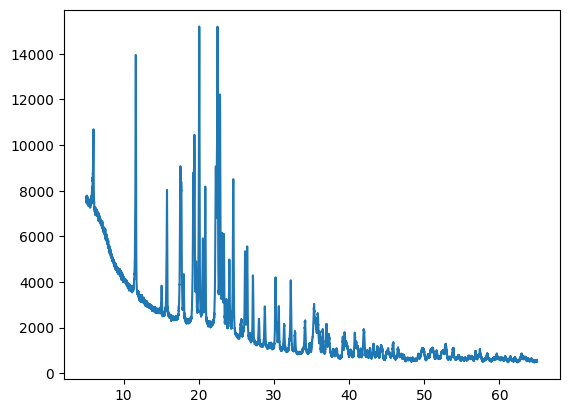

In [43]:
plt.plot(pxrd_clean2[:,0], pxrd_clean2[:, 1])

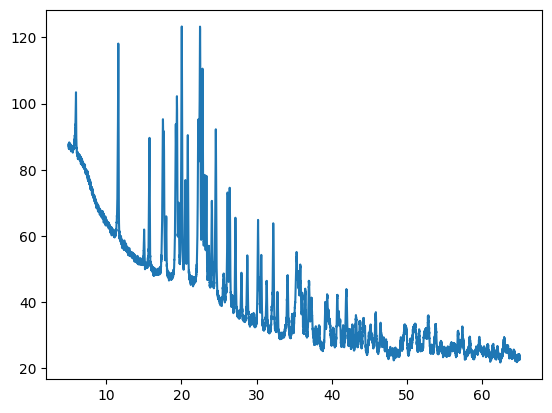

In [44]:
plt.plot(pxrd_clean2[:,0], pxrd_clean2[:, 2])

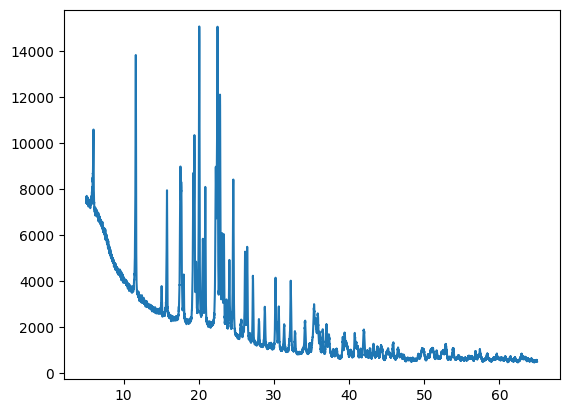

In [45]:
plt.plot(pxrd_clean2[:,0], pxrd_clean2[:, 1] - pxrd_clean2[:, 2])